# Battery Remaining Useful Life — Regression Modeling

This notebook presents a complete machine learning pipeline for predicting `remaining_useful_cycles` in lithium-ion battery packs. The pipeline covers data loading, exploratory data analysis, data cleaning, feature engineering, model training and hyperparameter tuning using multiple algorithms, and comprehensive model evaluation including explainability via SHAP values.

The dataset contains per-cycle observations from 200 batteries spanning multiple chemistries (LFP, NMC, NCA), climate zones, and usage strategies. The target variable `remaining_useful_cycles` represents the number of charge-discharge cycles a battery can still complete before reaching its end-of-life threshold.

## 1. Library Imports

All dependencies are imported upfront. Core scientific computing libraries are loaded alongside the machine learning frameworks used for modeling: scikit-learn for baseline models and preprocessing, XGBoost and LightGBM as gradient-boosted tree implementations, CatBoost as the categorical-native booster, and Optuna for automated hyperparameter optimization. SHAP is used for post-hoc model explainability.

In [7]:
import os
import warnings
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
import shap
import optuna

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

SEED = 42
np.random.seed(SEED)

BASE_DIR  = os.path.join('..', 'Dataset')
MODEL_DIR = os.path.join('.', 'model_artifacts')
os.makedirs(MODEL_DIR, exist_ok=True)

print('All libraries loaded successfully.')
print('Model artifacts will be saved to:', os.path.abspath(MODEL_DIR))

All libraries loaded successfully.
Model artifacts will be saved to: c:\Users\admin\Documents\Portofolio\Battery Remaining Useful Life\Model\model_artifacts


## 2. Data Loading

Four files constitute the full dataset:

| File | Description |
|---|---|
| `battery_observations.csv` | Per-cycle sensor and operational readings for all 200 batteries |
| `battery_metadata.csv` | Static battery attributes: chemistry, manufacturer, climate zone, capacity, usage strategy |
| `train_batteries.csv` | Battery IDs designated for training (140 batteries) |
| `validation_batteries.csv` | Battery IDs designated for validation (30 batteries) |
| `test_batteries.csv` | Battery IDs designated for final evaluation (30 batteries) |

The train/validation/test split is battery-level, ensuring that cycles from the same battery never appear in more than one split. This reflects a realistic deployment scenario where the model is evaluated on entirely unseen batteries.

In [8]:
obs       = pd.read_csv(os.path.join(BASE_DIR, 'battery_observations.csv'))
meta      = pd.read_csv(os.path.join(BASE_DIR, 'battery_metadata.csv'))
train_ids = pd.read_csv(os.path.join(BASE_DIR, 'train_batteries.csv'))['battery_id'].tolist()
val_ids   = pd.read_csv(os.path.join(BASE_DIR, 'validation_batteries.csv'))['battery_id'].tolist()
test_ids  = pd.read_csv(os.path.join(BASE_DIR, 'test_batteries.csv'))['battery_id'].tolist()

print('Observations shape  :', obs.shape)
print('Metadata shape      :', meta.shape)
print('Train batteries     :', len(train_ids))
print('Validation batteries:', len(val_ids))
print('Test batteries      :', len(test_ids))

Observations shape  : (172779, 31)
Metadata shape      : (200, 7)
Train batteries     : 140
Validation batteries: 30
Test batteries      : 30


## 3. Exploratory Data Analysis

Before any transformations are applied, the raw data is examined to understand its structure, quality, and statistical properties. This section covers missing value analysis, target variable distribution, feature correlations, and key domain-relevant relationships.

### 3.1 Schema and Missing Value Overview

In [9]:
print('=== Data Types ===')
print(obs.dtypes)
print()

missing     = obs.isnull().sum()
missing     = missing[missing > 0]
missing_pct = (missing / len(obs) * 100).round(2)
print('=== Missing Value Summary ===')
print(pd.concat([missing, missing_pct], axis=1, keys=['Count', 'Percent (%)']))

=== Data Types ===
battery_id                             str
timestamp                              str
cycle_index                          int64
battery_age_days                   float64
time_since_previous_cycle_hours    float64
equivalent_full_cycles             float64
soc_start_pct                      float64
soc_end_pct                        float64
depth_of_discharge_pct             float64
high_soc_exposure_fraction         float64
low_soc_exposure_fraction          float64
charge_c_rate                      float64
discharge_c_rate                   float64
charge_current_a                   float64
discharge_current_a                float64
charge_duration_min                float64
discharge_duration_min             float64
energy_discharged_kwh              float64
ambient_temp_c                     float64
pack_temp_c                        float64
cumulative_high_temp_hours         float64
cooling_active                       int64
pack_voltage_mean_v                

### 3.2 Target Variable Distribution

Rows where `remaining_useful_cycles` is null correspond to batteries that have already reached end-of-life or batteries that lack recorded end-of-life events within the observation window. These rows are not usable for supervised regression and are dropped before modeling. The distribution of the target is examined for skewness to decide whether a log transformation is beneficial.

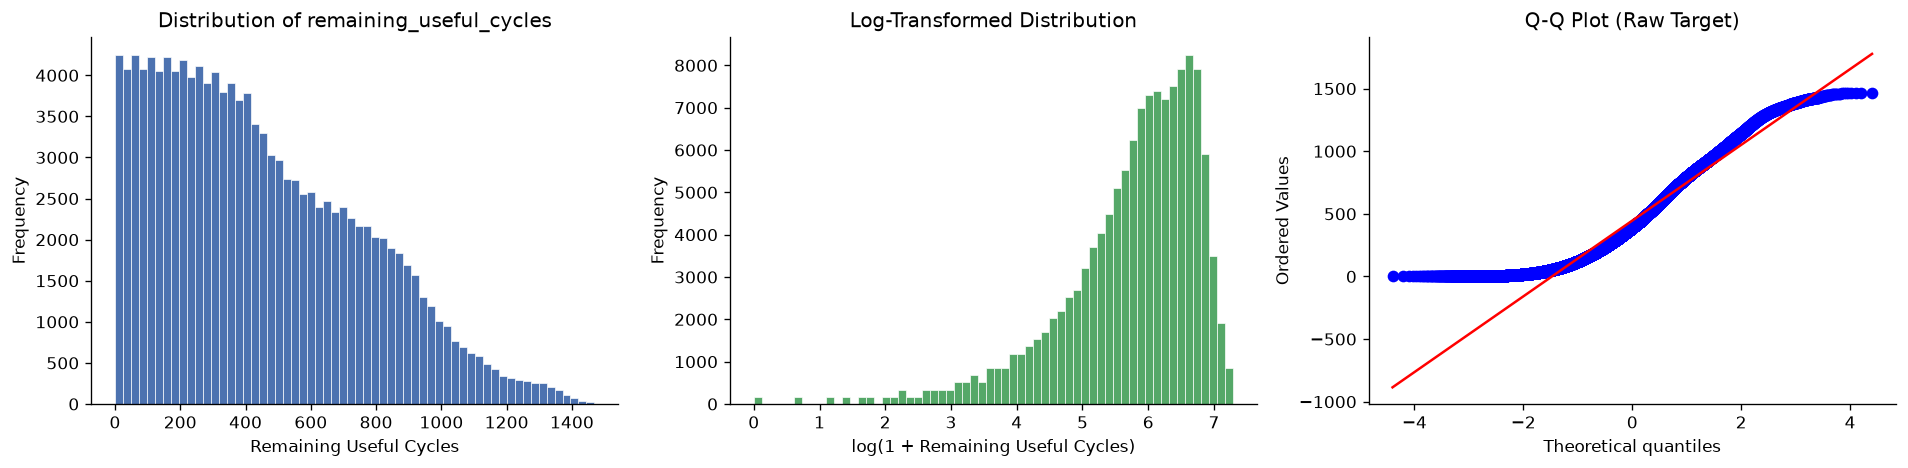

Skewness (raw)  : 0.6246
Skewness (log1p): -1.5086
Mean            : 446.12
Median          : 391.0
Std             : 310.14
Min / Max       : 0.0 / 1469.0


In [10]:
target_col = 'remaining_useful_cycles'
ruc_valid  = obs[target_col].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(ruc_valid, bins=60, color='#4C72B0', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribution of remaining_useful_cycles')
axes[0].set_xlabel('Remaining Useful Cycles')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(ruc_valid), bins=60, color='#55A868', edgecolor='white', linewidth=0.4)
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('log(1 + Remaining Useful Cycles)')
axes[1].set_ylabel('Frequency')

stats.probplot(ruc_valid, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Raw Target)')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'target_distribution.png'), bbox_inches='tight')
plt.show()

print('Skewness (raw)  :', round(ruc_valid.skew(), 4))
print('Skewness (log1p):', round(np.log1p(ruc_valid).skew(), 4))
print('Mean            :', round(ruc_valid.mean(), 2))
print('Median          :', round(ruc_valid.median(), 2))
print('Std             :', round(ruc_valid.std(), 2))
print('Min / Max       :', ruc_valid.min(), '/', ruc_valid.max())

### 3.3 Target Distribution by Battery Metadata

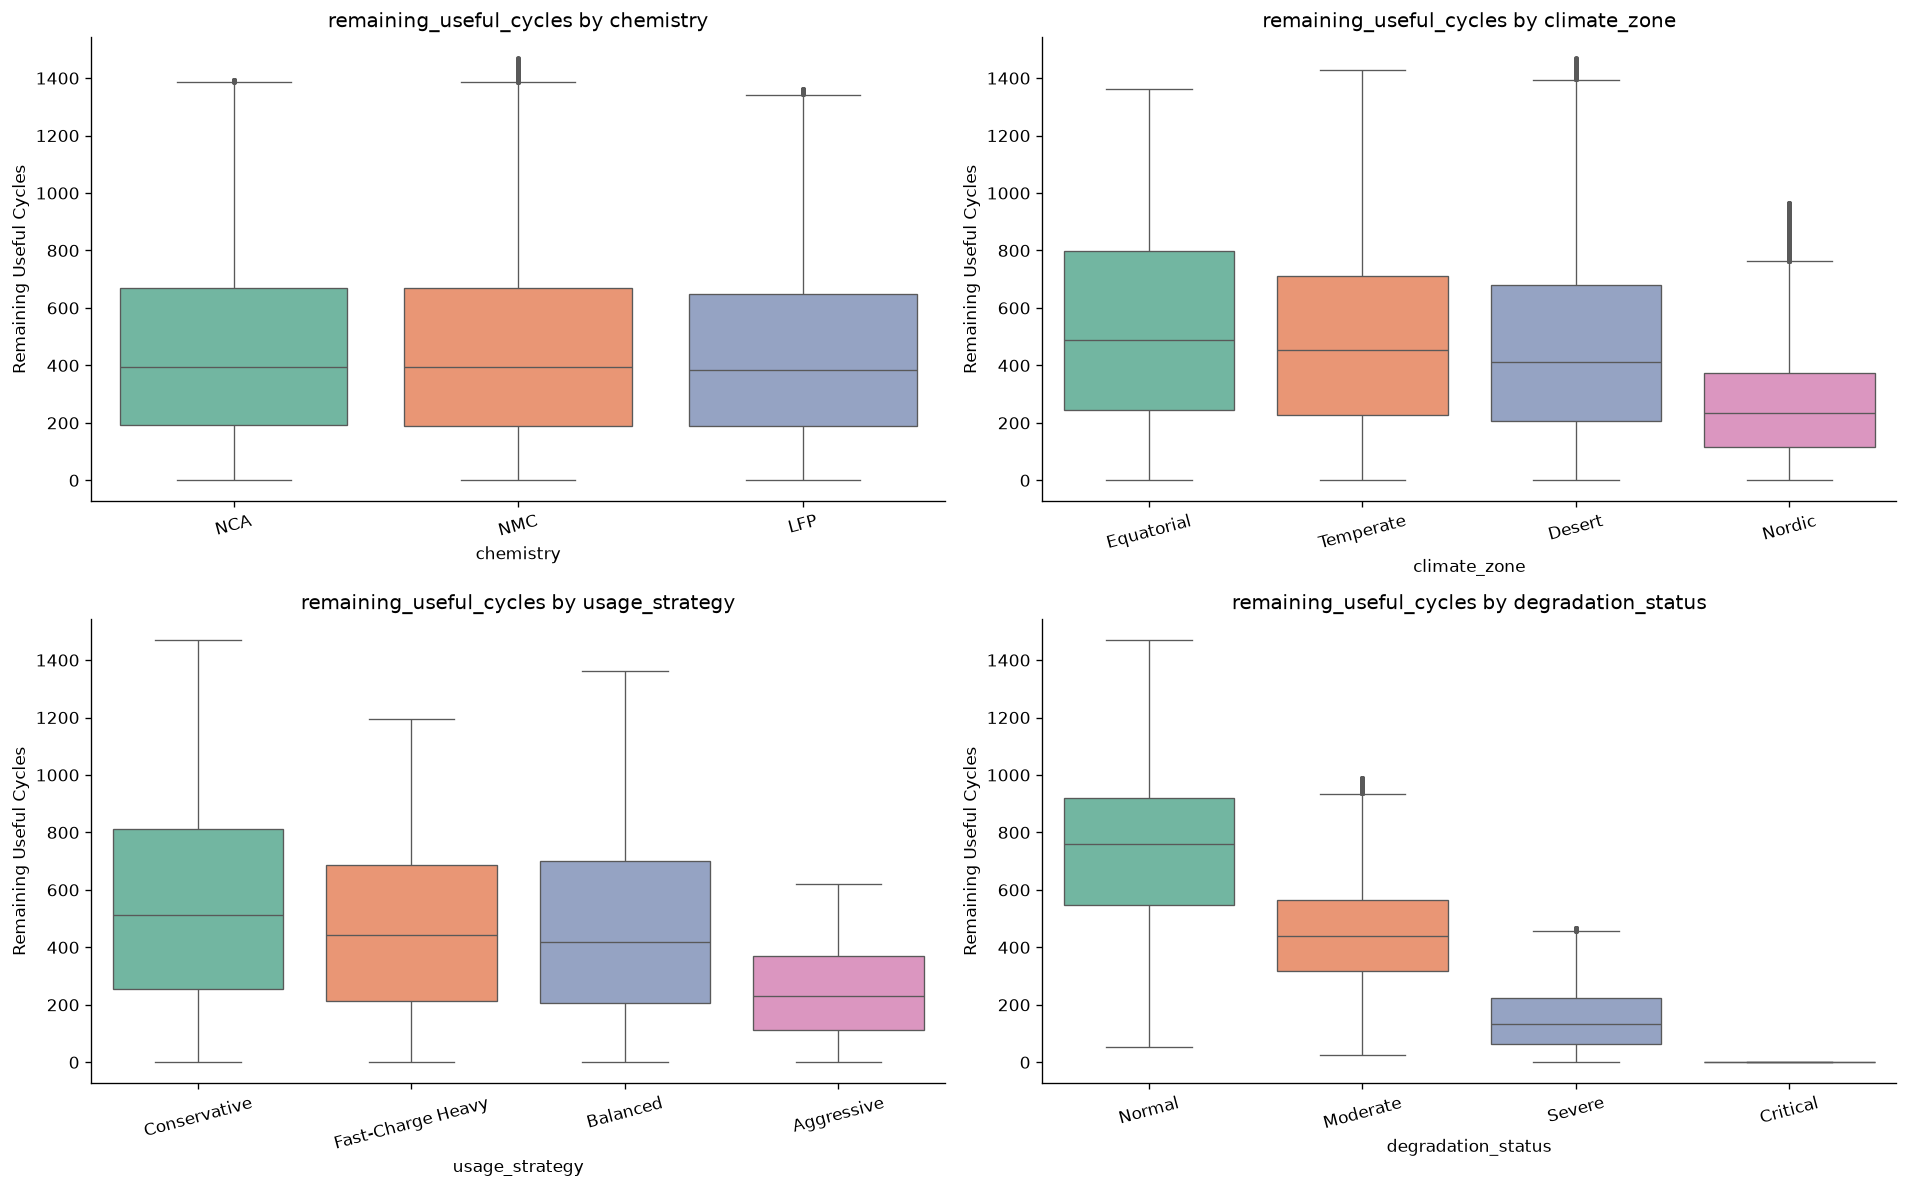

In [11]:
df_eda   = obs[obs[target_col].notna()].merge(meta, on='battery_id', how='left')
cat_cols = ['chemistry', 'climate_zone', 'usage_strategy', 'degradation_status']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
palette   = sns.color_palette('Set2')

for ax, col in zip(axes.ravel(), cat_cols):
    order = df_eda.groupby(col)[target_col].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df_eda, x=col, y=target_col, order=order,
        palette=palette, ax=ax, linewidth=0.8, fliersize=2
    )
    ax.set_title(target_col + ' by ' + col)
    ax.set_xlabel(col)
    ax.set_ylabel('Remaining Useful Cycles')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'target_by_category.png'), bbox_inches='tight')
plt.show()

### 3.4 Numeric Feature Correlation with Target

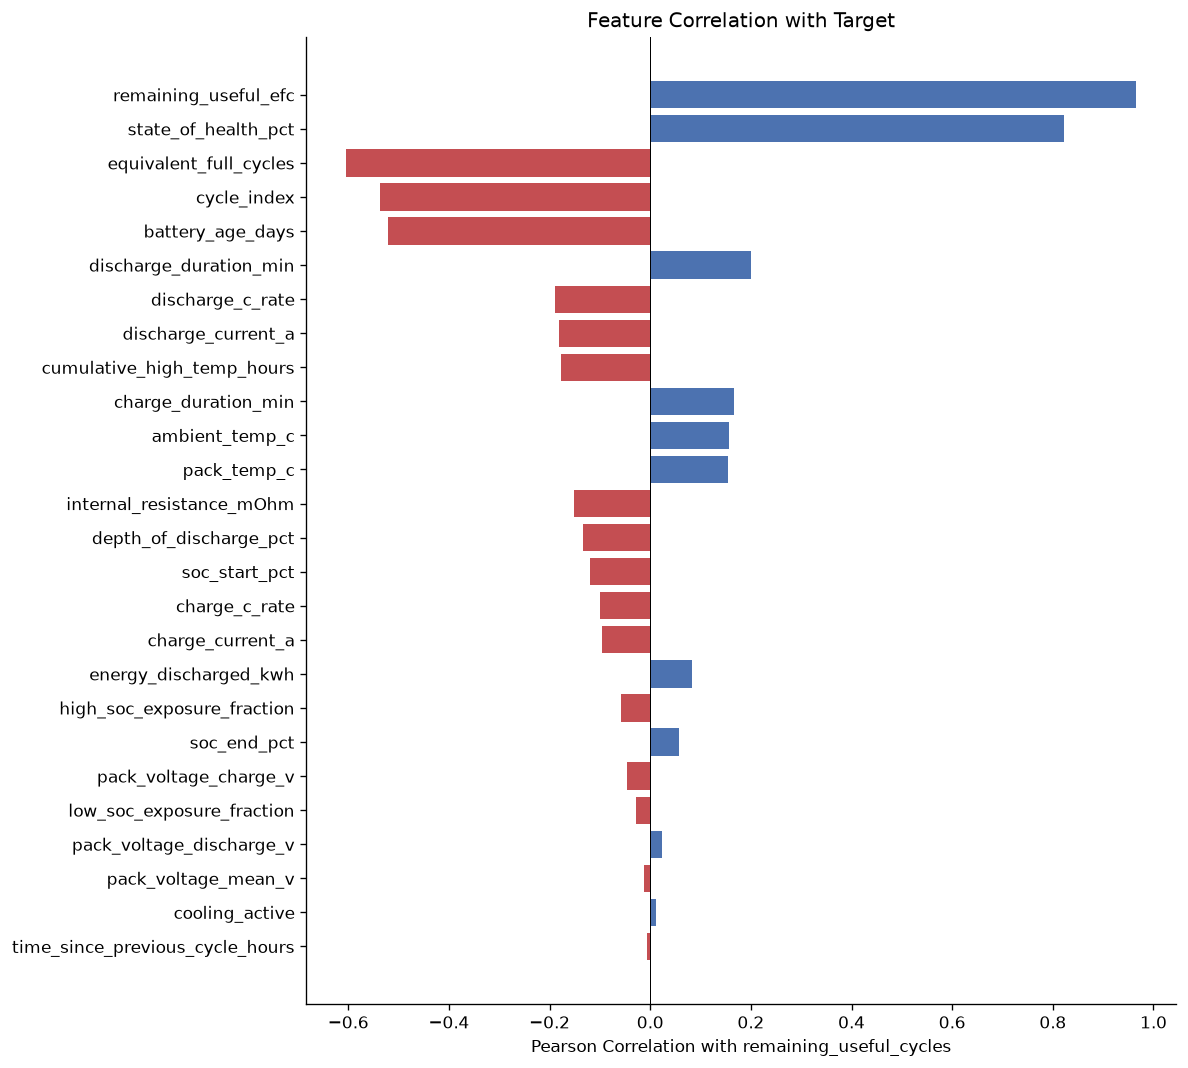

remaining_useful_efc          0.966167
state_of_health_pct           0.821828
equivalent_full_cycles       -0.604851
cycle_index                  -0.537316
battery_age_days             -0.520247
discharge_duration_min        0.199303
discharge_c_rate             -0.189303
discharge_current_a          -0.181861
cumulative_high_temp_hours   -0.177454
charge_duration_min           0.165686


In [12]:
num_cols = obs.select_dtypes(include=np.number).columns.tolist()
num_cols_no_target = [c for c in num_cols if c != target_col]

corr_with_target = (
    obs[num_cols_no_target + [target_col]]
    .dropna(subset=[target_col])
    .corr(numeric_only=True)[target_col]
    .drop(target_col, errors='ignore')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 9))
colors  = ['#4C72B0' if v > 0 else '#C44E52' for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Pearson Correlation with remaining_useful_cycles')
ax.set_title('Feature Correlation with Target')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'feature_correlation.png'), bbox_inches='tight')
plt.show()

print(corr_with_target.head(10).to_string())

### 3.5 Degradation Trajectories (Sample Batteries)

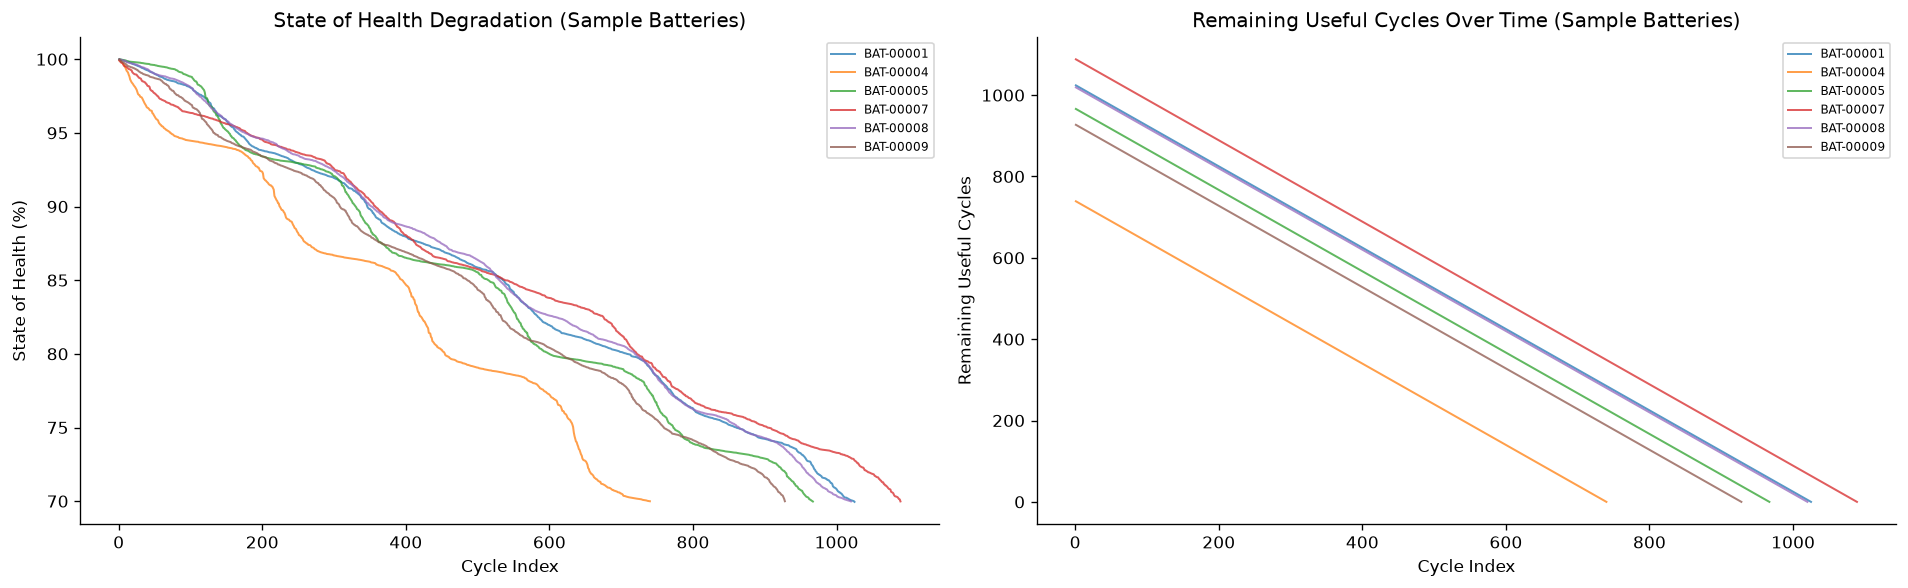

In [13]:
sample_batteries = train_ids[:6]
df_sample        = obs[obs['battery_id'].isin(sample_batteries) & obs[target_col].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for bat in sample_batteries:
    subset = df_sample[df_sample['battery_id'] == bat].sort_values('cycle_index')
    axes[0].plot(subset['cycle_index'], subset['state_of_health_pct'], alpha=0.75, linewidth=1.2)
    axes[1].plot(subset['cycle_index'], subset[target_col], alpha=0.75, linewidth=1.2)

axes[0].set_title('State of Health Degradation (Sample Batteries)')
axes[0].set_xlabel('Cycle Index')
axes[0].set_ylabel('State of Health (%)')
axes[0].legend(sample_batteries, fontsize=7, loc='upper right')

axes[1].set_title('Remaining Useful Cycles Over Time (Sample Batteries)')
axes[1].set_xlabel('Cycle Index')
axes[1].set_ylabel('Remaining Useful Cycles')
axes[1].legend(sample_batteries, fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'degradation_trajectories.png'), bbox_inches='tight')
plt.show()

## 4. Data Cleaning

The cleaning stage addresses the following issues identified during EDA:

1. **Rows with missing target**: Observations where `remaining_useful_cycles` is null are removed. These are batteries that did not reach end-of-life within the recording window and therefore have no ground truth label for regression.
2. **`pack_temp_c` missing values**: Approximately 1% of rows are missing pack temperature readings. These are imputed using the median temperature per battery, falling back to the global median.
3. **Leaky features**: `remaining_useful_efc` and `eol_reached` are direct derivatives of the target and would constitute data leakage. They are excluded.
4. **Non-predictive identifiers**: `battery_id` and `timestamp` are dropped from the feature matrix (battery_id is used only for merging metadata).
5. **`degradation_status`**: Retained as an ordinal feature since it captures discretized severity of battery degradation.

In [14]:
LEAKY_COLS = ['remaining_useful_efc', 'eol_reached']
ID_COLS    = ['battery_id', 'timestamp']

df = obs.copy()
print('Initial rows       :', len(df))

df = df[df[target_col].notna()].copy()
print('After target filter:', len(df))

df = df.merge(
    meta[['battery_id', 'chemistry', 'manufacturer', 'climate_zone', 'nominal_capacity_kwh', 'usage_strategy']],
    on='battery_id', how='left'
)

temp_median_per_bat = df.groupby('battery_id')['pack_temp_c'].transform('median')
global_temp_median  = df['pack_temp_c'].median()
df['pack_temp_c']   = df['pack_temp_c'].fillna(temp_median_per_bat).fillna(global_temp_median)

df = df.drop(columns=LEAKY_COLS + ID_COLS, errors='ignore')

assert df.isnull().sum().sum() == 0, 'Unexpected nulls remain after cleaning.'
print('Final cleaned rows :', len(df))
print('Features available :', df.shape[1] - 1)

Initial rows       : 172779
After target filter: 129523
Final cleaned rows : 129523
Features available : 31


## 5. Feature Engineering

Beyond the raw sensor readings, several domain-informed derived features are constructed to improve the model's ability to capture non-linear degradation dynamics:

- **`soc_swing`**: The difference between the starting and ending state-of-charge captures effective utilization depth per cycle.
- **`charge_discharge_ratio`**: The ratio of charge to discharge C-rates reveals asymmetric stress patterns.
- **`temp_stress`**: The absolute deviation of pack temperature from an optimal 25 C operating point, weighted by cumulative high-temperature exposure.
- **`energy_per_efc`**: Energy discharged normalized by equivalent full cycles, a proxy for per-cycle efficiency.
- **`voltage_window`**: The spread between charge and discharge voltages, which narrows as internal resistance increases.
- **`cycle_age_ratio`**: The ratio of cycle index to battery age in days, encoding charging frequency over the battery's lifetime.
- **`soh_degradation_rate`**: A rolling approximation of the rate at which state-of-health is declining, computed as SoH divided by cycle index.

In [15]:
df['soc_swing']              = df['soc_start_pct'] - df['soc_end_pct']
df['charge_discharge_ratio'] = df['charge_c_rate'] / (df['discharge_c_rate'] + 1e-6)
df['temp_stress']            = (df['pack_temp_c'] - 25).abs() * (1 + df['cumulative_high_temp_hours'] / 100)
df['energy_per_efc']         = df['energy_discharged_kwh'] / (df['equivalent_full_cycles'] + 1e-6)
df['voltage_window']         = df['pack_voltage_charge_v'] - df['pack_voltage_discharge_v']
df['cycle_age_ratio']        = df['cycle_index'] / (df['battery_age_days'] + 1e-6)
df['soh_degradation_rate']   = df['state_of_health_pct'] / (df['cycle_index'] + 1)

print('Feature engineering complete.')
print('Total columns:', df.shape[1])
print('New features:', ['soc_swing', 'charge_discharge_ratio', 'temp_stress',
                        'energy_per_efc', 'voltage_window', 'cycle_age_ratio', 'soh_degradation_rate'])

Feature engineering complete.
Total columns: 39
New features: ['soc_swing', 'charge_discharge_ratio', 'temp_stress', 'energy_per_efc', 'voltage_window', 'cycle_age_ratio', 'soh_degradation_rate']


## 6. Train / Validation / Test Split

The battery-level split defined in the original dataset files is respected. Features and targets are separated, and categorical columns are identified for appropriate encoding.

In [16]:
battery_id_series = obs.loc[df.index, 'battery_id']

train_mask = battery_id_series.isin(train_ids)
val_mask   = battery_id_series.isin(val_ids)
test_mask  = battery_id_series.isin(test_ids)

df_train = df[train_mask].copy()
df_val   = df[val_mask].copy()
df_test  = df[test_mask].copy()

feature_cols = [c for c in df.columns if c != target_col]

X_train, y_train = df_train[feature_cols], df_train[target_col]
X_val,   y_val   = df_val[feature_cols],   df_val[target_col]
X_test,  y_test  = df_test[feature_cols],  df_test[target_col]

CAT_COLS = ['chemistry', 'manufacturer', 'climate_zone', 'usage_strategy', 'degradation_status']
NUM_COLS = [c for c in feature_cols if c not in CAT_COLS]

print('Train  :', X_train.shape[0], 'rows')
print('Val    :', X_val.shape[0],   'rows')
print('Test   :', X_test.shape[0],  'rows')
print('Numeric features   :', len(NUM_COLS))
print('Categorical features:', len(CAT_COLS))

Train  : 89625 rows
Val    : 18999 rows
Test   : 20899 rows
Numeric features   : 33
Categorical features: 5


## 7. Preprocessing Pipeline

A `ColumnTransformer` is used to apply separate preprocessing steps to numeric and categorical features:

- **Numeric features** are scaled with `RobustScaler`, which is resistant to outliers because it uses the interquartile range rather than the standard deviation. A median imputer is included as a safety net.
- **Categorical features** are encoded with `OrdinalEncoder`. Tree-based models do not require one-hot encoding and perform better with ordinal integer codes because they can leverage ordered splits.

The preprocessor is fitted exclusively on the training set and then applied to validation and test sets to prevent data leakage.

In [17]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        encoded_missing_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     NUM_COLS),
    ('cat', categorical_transformer, CAT_COLS)
], remainder='drop')

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

all_feature_names = NUM_COLS + CAT_COLS

joblib.dump(preprocessor, os.path.join(MODEL_DIR, 'preprocessor.joblib'))
print('Preprocessed train shape:', X_train_proc.shape)
print('Preprocessor saved.')

Preprocessed train shape: (89625, 38)
Preprocessor saved.


## 8. Baseline Models

Before tuning, a set of candidate models is evaluated with default hyperparameters to establish a performance baseline. The models span a range of complexity levels, from linear regularized regression to ensemble tree methods. Performance is measured on the validation set using:

- **MAE** (Mean Absolute Error): Average magnitude of prediction errors in cycle units.
- **RMSE** (Root Mean Squared Error): Penalizes large errors more heavily than MAE.
- **MAPE** (Mean Absolute Percentage Error): Scale-free relative error.
- **R2** (Coefficient of Determination): Proportion of variance explained by the model.

In [18]:
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    return {'Model': label, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R2': r2}


baseline_models = {
    'Ridge':        Ridge(alpha=1.0),
    'Lasso':        Lasso(alpha=0.1),
    'ElasticNet':   ElasticNet(alpha=0.1, l1_ratio=0.5),
    'ExtraTrees':   ExtraTreesRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGBoost':      XGBRegressor(n_estimators=200, random_state=SEED, n_jobs=-1, verbosity=0),
    'LightGBM':     LGBMRegressor(n_estimators=200, random_state=SEED, n_jobs=-1, verbose=-1),
    'CatBoost':     CatBoostRegressor(iterations=200, random_seed=SEED, verbose=0)
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train_proc, y_train)
    preds   = np.clip(model.predict(X_val_proc), 0, None)
    metrics = evaluate(y_val, preds, label=name)
    baseline_results.append(metrics)
    print(name.ljust(20), '| MAE=', round(metrics['MAE'], 2),
          '| RMSE=', round(metrics['RMSE'], 2), '| R2=', round(metrics['R2'], 4))

baseline_df = pd.DataFrame(baseline_results).set_index('Model').round(4)
print()
print(baseline_df.sort_values('RMSE'))

Ridge                | MAE= 103.92 | RMSE= 141.6 | R2= 0.7788
Lasso                | MAE= 103.03 | RMSE= 140.95 | R2= 0.7808
ElasticNet           | MAE= 123.39 | RMSE= 160.01 | R2= 0.7175
ExtraTrees           | MAE= 35.54 | RMSE= 51.35 | R2= 0.9709
RandomForest         | MAE= 43.44 | RMSE= 80.76 | R2= 0.928
XGBoost              | MAE= 39.73 | RMSE= 59.06 | R2= 0.9615
LightGBM             | MAE= 38.53 | RMSE= 62.59 | R2= 0.9568
CatBoost             | MAE= 41.3 | RMSE= 60.44 | R2= 0.9597

                   MAE      RMSE      MAPE (%)      R2
Model                                                 
ExtraTrees     35.5449   51.3517  3.658301e+15  0.9709
XGBoost        39.7301   59.0627  6.803889e+15  0.9615
CatBoost       41.2952   60.4375  5.746565e+15  0.9597
LightGBM       38.5266   62.5892  3.166358e+15  0.9568
RandomForest   43.4415   80.7568  4.740881e+11  0.9280
Lasso         103.0294  140.9550  1.203620e+16  0.7808
Ridge         103.9163  141.5970  1.226453e+16  0.7788
ElasticNet   

### 8.1 Baseline Comparison Chart

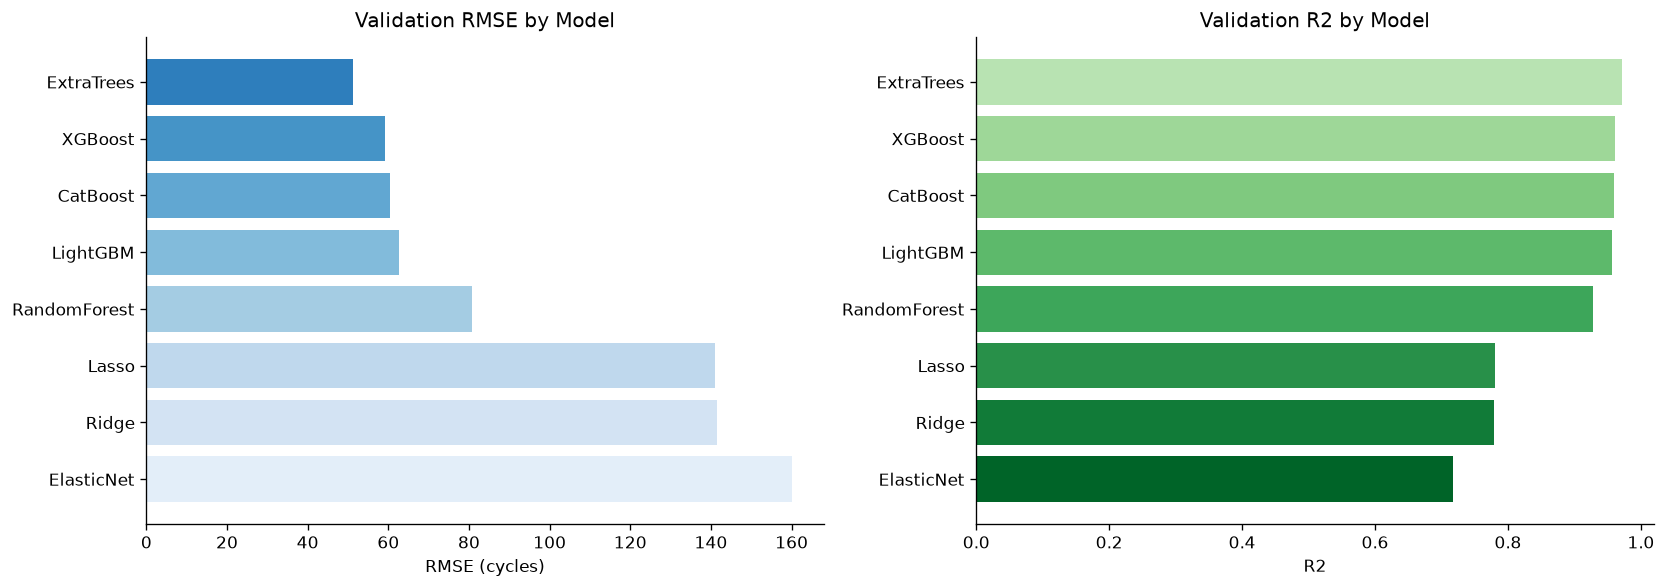

In [19]:
sorted_df    = baseline_df.sort_values('RMSE')
colors_rmse  = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(sorted_df)))
sorted_r2    = baseline_df.sort_values('R2', ascending=False)
colors_r2    = plt.cm.Greens(np.linspace(0.3, 0.9, len(sorted_r2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(sorted_df.index[::-1], sorted_df['RMSE'][::-1], color=colors_rmse[::-1])
axes[0].set_title('Validation RMSE by Model')
axes[0].set_xlabel('RMSE (cycles)')

axes[1].barh(sorted_r2.index[::-1], sorted_r2['R2'][::-1], color=colors_r2[::-1])
axes[1].set_title('Validation R2 by Model')
axes[1].set_xlabel('R2')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'baseline_comparison.png'), bbox_inches='tight')
plt.show()

## 9. Hyperparameter Tuning with Optuna

The top-performing models from the baseline evaluation are tuned using Optuna, a Bayesian optimization framework. Optuna uses Tree-structured Parzen Estimators (TPE) to efficiently search the hyperparameter space, focusing trials on promising regions rather than exhaustively evaluating a grid.

Three models are tuned independently:
- **XGBoost**: Gradient-boosted trees with regularization and subsampling.
- **LightGBM**: Leaf-wise boosting with histogram-based splits, optimized for speed.
- **CatBoost**: Symmetric tree boosting with ordered target statistics.

All studies minimize validation RMSE with 60 trials each.

In [20]:
N_TRIALS = 60

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': SEED, 'n_jobs': -1, 'verbosity': 0
    }
    m = XGBRegressor(**params)
    m.fit(X_train_proc, y_train)
    return np.sqrt(mean_squared_error(y_val, np.clip(m.predict(X_val_proc), 0, None)))


def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 16, 256),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': SEED, 'n_jobs': -1, 'verbose': -1
    }
    m = LGBMRegressor(**params)
    m.fit(X_train_proc, y_train)
    return np.sqrt(mean_squared_error(y_val, np.clip(m.predict(X_val_proc), 0, None)))


def cat_objective(trial):
    params = {
        'iterations':        trial.suggest_int('iterations', 200, 1000),
        'depth':             trial.suggest_int('depth', 4, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'random_seed': SEED, 'verbose': 0
    }
    m = CatBoostRegressor(**params)
    m.fit(X_train_proc, y_train)
    return np.sqrt(mean_squared_error(y_val, np.clip(m.predict(X_val_proc), 0, None)))


print('Tuning XGBoost...')
study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS)
print('  Best XGB RMSE :', round(study_xgb.best_value, 4))

print('Tuning LightGBM...')
study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS)
print('  Best LGB RMSE :', round(study_lgb.best_value, 4))

print('Tuning CatBoost...')
study_cat = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(cat_objective, n_trials=N_TRIALS)
print('  Best CAT RMSE :', round(study_cat.best_value, 4))

Tuning XGBoost...
  Best XGB RMSE : 55.5625
Tuning LightGBM...
  Best LGB RMSE : 54.1045
Tuning CatBoost...
  Best CAT RMSE : 53.4489


### 9.1 Optuna Optimization History

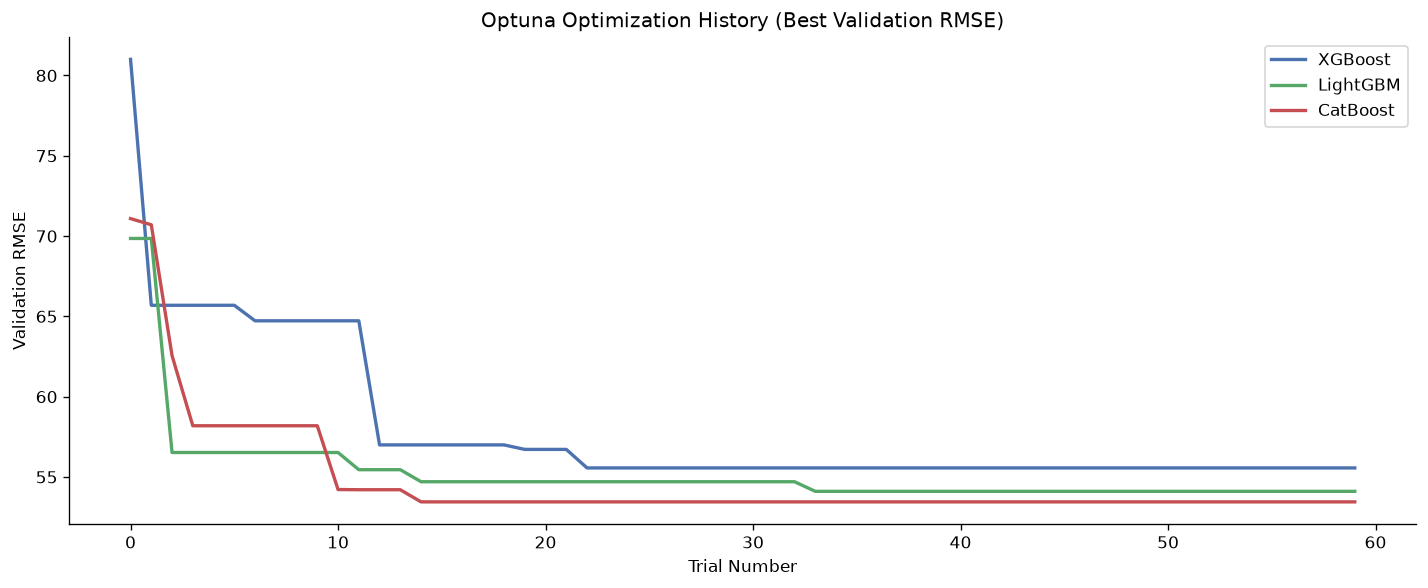

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

for study, label, color in [
    (study_xgb, 'XGBoost',  '#4C72B0'),
    (study_lgb, 'LightGBM', '#55A868'),
    (study_cat, 'CatBoost', '#C44E52')
]:
    trials        = sorted(study.trials, key=lambda t: t.number)
    best_so_far   = []
    current_best  = float('inf')
    for t in trials:
        if t.value is not None and t.value < current_best:
            current_best = t.value
        best_so_far.append(current_best)
    ax.plot(best_so_far, label=label, color=color, linewidth=2)

ax.set_title('Optuna Optimization History (Best Validation RMSE)')
ax.set_xlabel('Trial Number')
ax.set_ylabel('Validation RMSE')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'optuna_history.png'), bbox_inches='tight')
plt.show()

## 10. Final Model Training

The three tuned models are retrained on the combined training and validation sets using their best hyperparameters. Using more data at this stage allows the models to generalize better before final evaluation on the held-out test set.

In [22]:
X_trainval_proc = np.vstack([X_train_proc, X_val_proc])
y_trainval      = np.concatenate([y_train.values, y_val.values])

best_xgb = XGBRegressor(**{**study_xgb.best_params, 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0})
best_lgb = LGBMRegressor(**{**study_lgb.best_params, 'random_state': SEED, 'n_jobs': -1, 'verbose': -1})
best_cat = CatBoostRegressor(**{**study_cat.best_params, 'random_seed': SEED, 'verbose': 0})

print('Training tuned XGBoost on train+val...')
best_xgb.fit(X_trainval_proc, y_trainval)

print('Training tuned LightGBM on train+val...')
best_lgb.fit(X_trainval_proc, y_trainval)

print('Training tuned CatBoost on train+val...')
best_cat.fit(X_trainval_proc, y_trainval)

joblib.dump(best_xgb, os.path.join(MODEL_DIR, 'best_xgboost.joblib'))
joblib.dump(best_lgb, os.path.join(MODEL_DIR, 'best_lightgbm.joblib'))
joblib.dump(best_cat, os.path.join(MODEL_DIR, 'best_catboost.joblib'))

print('All tuned models saved.')

Training tuned XGBoost on train+val...
Training tuned LightGBM on train+val...
Training tuned CatBoost on train+val...
All tuned models saved.


## 11. Weighted Ensemble

A weighted average ensemble combines the predictions of the three tuned models. The weights are derived from the inverse of each model's validation RMSE, so that the model with the lowest error contributes most strongly. This approach often reduces prediction variance without requiring a meta-learner.

In [23]:
val_rmse_xgb = np.sqrt(mean_squared_error(y_val, np.clip(best_xgb.predict(X_val_proc), 0, None)))
val_rmse_lgb = np.sqrt(mean_squared_error(y_val, np.clip(best_lgb.predict(X_val_proc), 0, None)))
val_rmse_cat = np.sqrt(mean_squared_error(y_val, np.clip(best_cat.predict(X_val_proc), 0, None)))

inv_rmse = np.array([1 / val_rmse_xgb, 1 / val_rmse_lgb, 1 / val_rmse_cat])
weights  = inv_rmse / inv_rmse.sum()

print('XGBoost  val RMSE:', round(val_rmse_xgb, 4), ' -> weight:', round(weights[0], 4))
print('LightGBM val RMSE:', round(val_rmse_lgb, 4), ' -> weight:', round(weights[1], 4))
print('CatBoost val RMSE:', round(val_rmse_cat, 4), ' -> weight:', round(weights[2], 4))

with open(os.path.join(MODEL_DIR, 'ensemble_weights.json'), 'w') as f:
    json.dump({'xgboost': weights[0], 'lightgbm': weights[1], 'catboost': weights[2]}, f, indent=2)


def ensemble_predict(X_proc):
    p_xgb = np.clip(best_xgb.predict(X_proc), 0, None)
    p_lgb = np.clip(best_lgb.predict(X_proc), 0, None)
    p_cat = np.clip(best_cat.predict(X_proc), 0, None)
    return weights[0] * p_xgb + weights[1] * p_lgb + weights[2] * p_cat


print('Ensemble weights saved.')

XGBoost  val RMSE: 13.3606  -> weight: 0.3327
LightGBM val RMSE: 11.9002  -> weight: 0.3735
CatBoost val RMSE: 15.1282  -> weight: 0.2938
Ensemble weights saved.


## 12. Final Evaluation on Test Set

All models, including individual tuned estimators and the ensemble, are evaluated on the held-out test batteries that were never seen during training or hyperparameter tuning. This is the definitive performance assessment.

In [24]:
final_results = []

for name, preds in [
    ('XGBoost (tuned)',  np.clip(best_xgb.predict(X_test_proc), 0, None)),
    ('LightGBM (tuned)', np.clip(best_lgb.predict(X_test_proc), 0, None)),
    ('CatBoost (tuned)', np.clip(best_cat.predict(X_test_proc), 0, None)),
    ('Ensemble',         ensemble_predict(X_test_proc))
]:
    metrics = evaluate(y_test, preds, label=name)
    final_results.append(metrics)
    print(
        name.ljust(22), '| MAE=', round(metrics['MAE'], 2),
        '| RMSE=', round(metrics['RMSE'], 2),
        '| MAPE=', round(metrics['MAPE (%)'], 2), '%',
        '| R2=', round(metrics['R2'], 4)
    )

final_df = pd.DataFrame(final_results).set_index('Model').round(4)
print()
print(final_df)

final_df.to_csv(os.path.join(MODEL_DIR, 'test_evaluation_results.csv'))
print('Test evaluation results saved.')

XGBoost (tuned)        | MAE= 42.69 | RMSE= 66.13 | MAPE= 3761492898184431.0 % | R2= 0.9592
LightGBM (tuned)       | MAE= 39.54 | RMSE= 61.96 | MAPE= 7817283192353609.0 % | R2= 0.9642
CatBoost (tuned)       | MAE= 40.76 | RMSE= 59.87 | MAPE= 6944219413658732.0 % | R2= 0.9665
Ensemble               | MAE= 39.42 | RMSE= 60.98 | MAPE= 6211479090260490.0 % | R2= 0.9653

                      MAE     RMSE      MAPE (%)      R2
Model                                                   
XGBoost (tuned)   42.6897  66.1304  3.761493e+15  0.9592
LightGBM (tuned)  39.5356  61.9644  7.817283e+15  0.9642
CatBoost (tuned)  40.7587  59.8668  6.944219e+15  0.9665
Ensemble          39.4181  60.9811  6.211479e+15  0.9653
Test evaluation results saved.


### 12.1 Residual Analysis

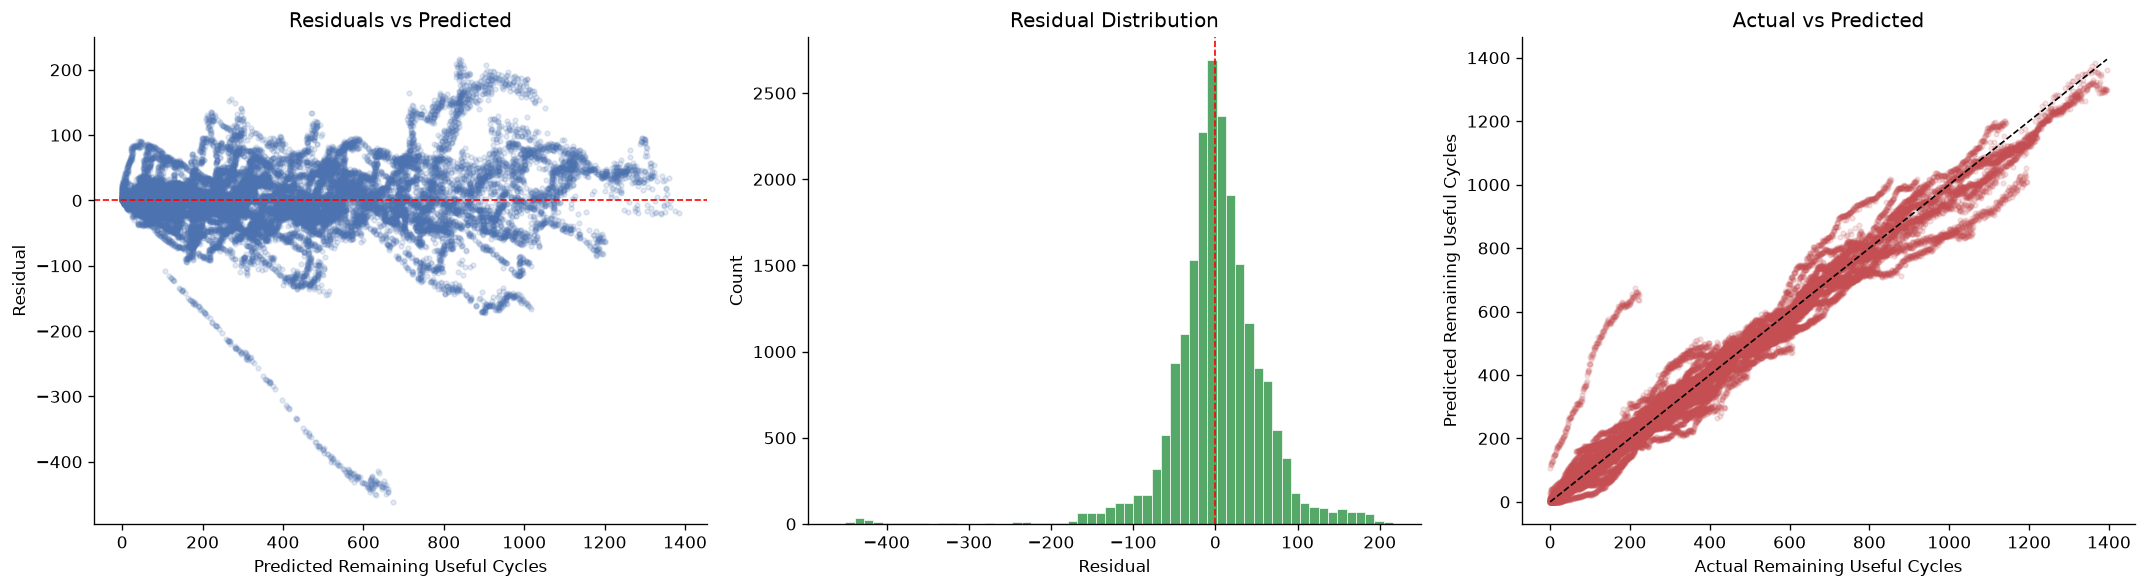

Mean Residual : 2.0522
Residual Std  : 60.9466
Residual Skew : -1.8017


In [25]:
best_preds = ensemble_predict(X_test_proc)
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best_preds, residuals, alpha=0.15, s=8, color='#4C72B0')
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Remaining Useful Cycles')
axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=60, color='#55A868', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[2].scatter(y_test, best_preds, alpha=0.15, s=8, color='#C44E52')
axes[2].plot(lims, lims, 'k--', linewidth=1)
axes[2].set_title('Actual vs Predicted')
axes[2].set_xlabel('Actual Remaining Useful Cycles')
axes[2].set_ylabel('Predicted Remaining Useful Cycles')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'residual_analysis.png'), bbox_inches='tight')
plt.show()

print('Mean Residual :', round(residuals.mean(), 4))
print('Residual Std  :', round(residuals.std(), 4))
print('Residual Skew :', round(pd.Series(residuals).skew(), 4))

### 12.2 Error Distribution by Segment

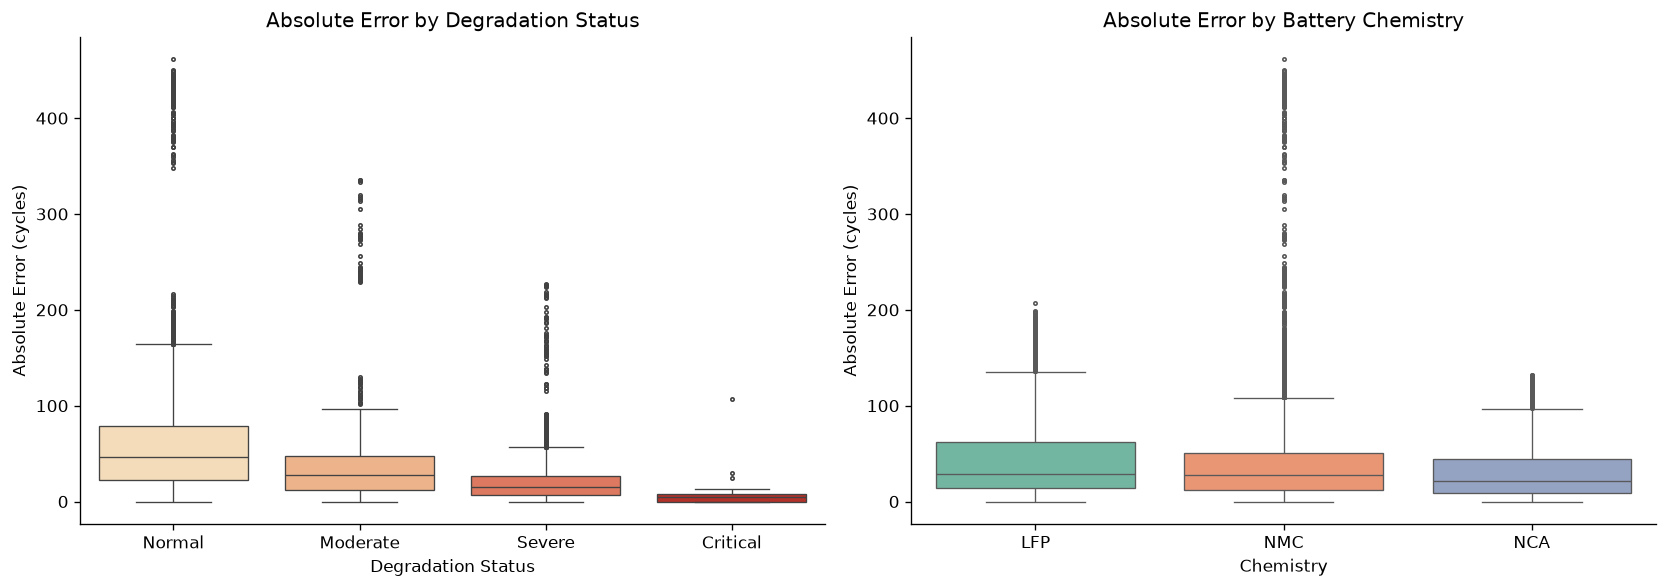

In [26]:
df_test_eval              = df_test.copy()
df_test_eval['predicted'] = best_preds
df_test_eval['abs_error'] = np.abs(y_test.values - best_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

deg_order = ['Normal', 'Moderate', 'Severe', 'Critical']
sns.boxplot(
    data=df_test_eval, x='degradation_status', y='abs_error',
    order=deg_order, palette='OrRd', ax=axes[0], linewidth=0.8, fliersize=2
)
axes[0].set_title('Absolute Error by Degradation Status')
axes[0].set_xlabel('Degradation Status')
axes[0].set_ylabel('Absolute Error (cycles)')

sns.boxplot(
    data=df_test_eval, x='chemistry', y='abs_error',
    palette='Set2', ax=axes[1], linewidth=0.8, fliersize=2
)
axes[1].set_title('Absolute Error by Battery Chemistry')
axes[1].set_xlabel('Chemistry')
axes[1].set_ylabel('Absolute Error (cycles)')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'error_by_segment.png'), bbox_inches='tight')
plt.show()

## 13. Feature Importance

### 13.1 Native Importance (Gain-based)

XGBoost and LightGBM provide native feature importance scores based on the total gain attributed to each feature across all split points. These scores are fast to compute but can be biased toward high-cardinality features.

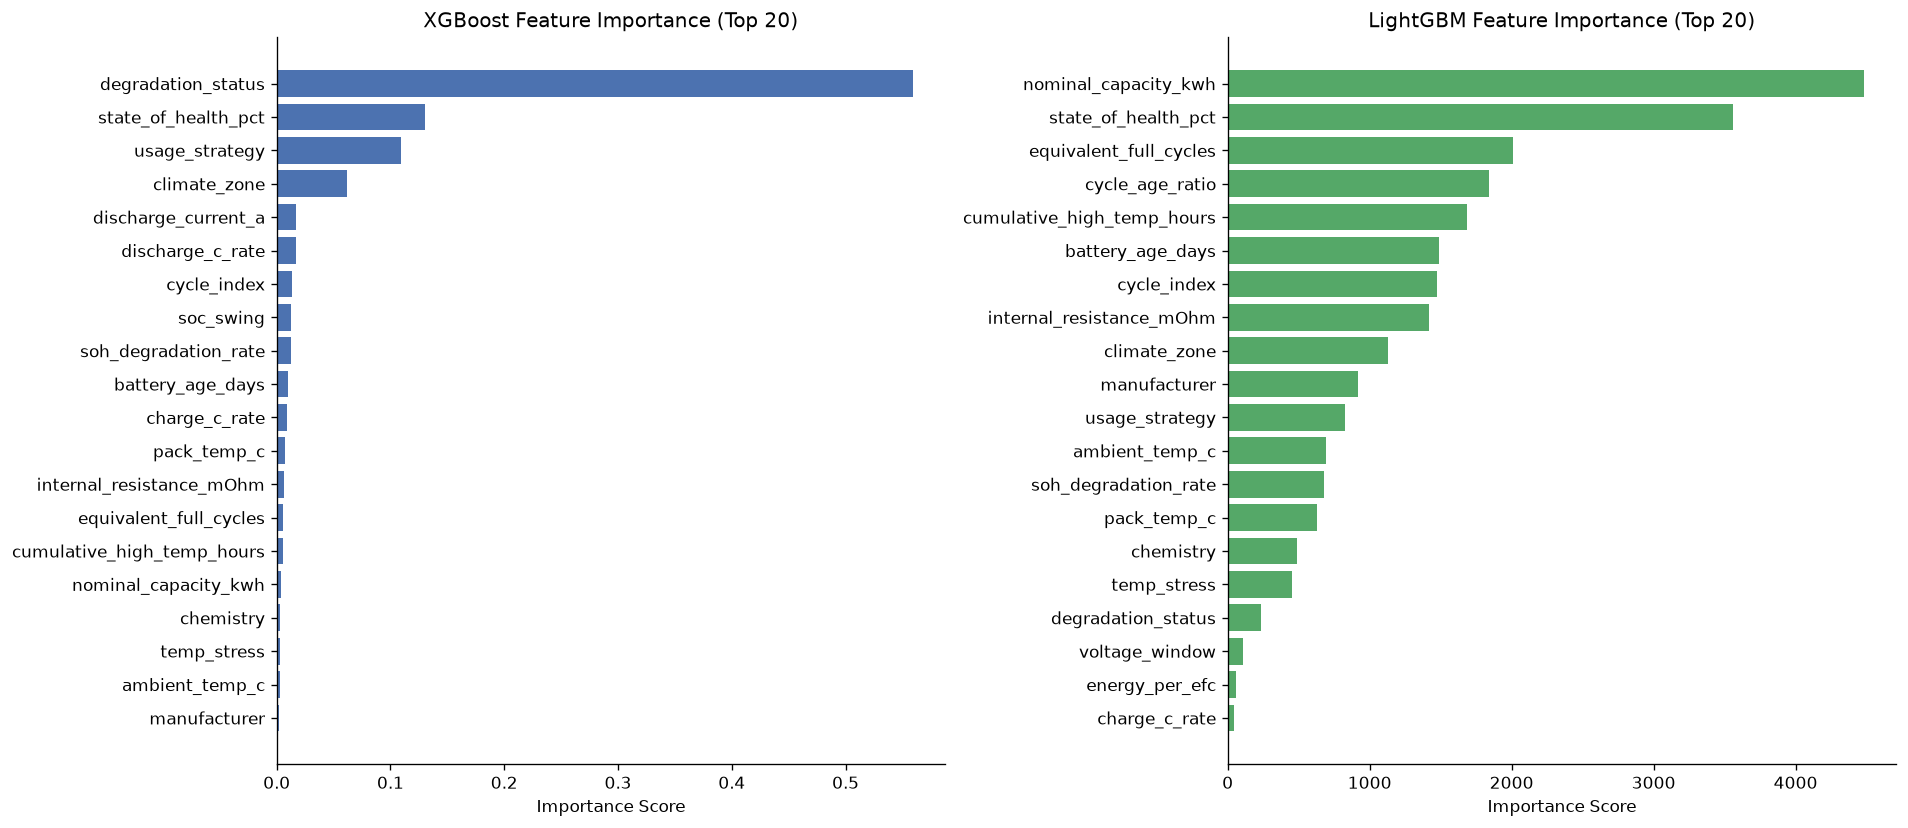

In [27]:
xgb_imp = pd.Series(best_xgb.feature_importances_, index=all_feature_names).sort_values(ascending=False)
lgb_imp = pd.Series(best_lgb.feature_importances_, index=all_feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(xgb_imp.head(20).index[::-1], xgb_imp.head(20).values[::-1], color='#4C72B0')
axes[0].set_title('XGBoost Feature Importance (Top 20)')
axes[0].set_xlabel('Importance Score')

axes[1].barh(lgb_imp.head(20).index[::-1], lgb_imp.head(20).values[::-1], color='#55A868')
axes[1].set_title('LightGBM Feature Importance (Top 20)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'feature_importance_native.png'), bbox_inches='tight')
plt.show()

### 13.2 SHAP Values

SHAP (SHapley Additive exPlanations) provides model-agnostic, game-theoretically grounded feature attribution. Each feature is assigned a SHAP value for every prediction, representing its marginal contribution to shifting the output away from the expected value. SHAP values are more reliable than gain-based importance because they account for feature interactions and do not favor high-cardinality features.

A subsample of 3,000 test observations is used for computational efficiency.

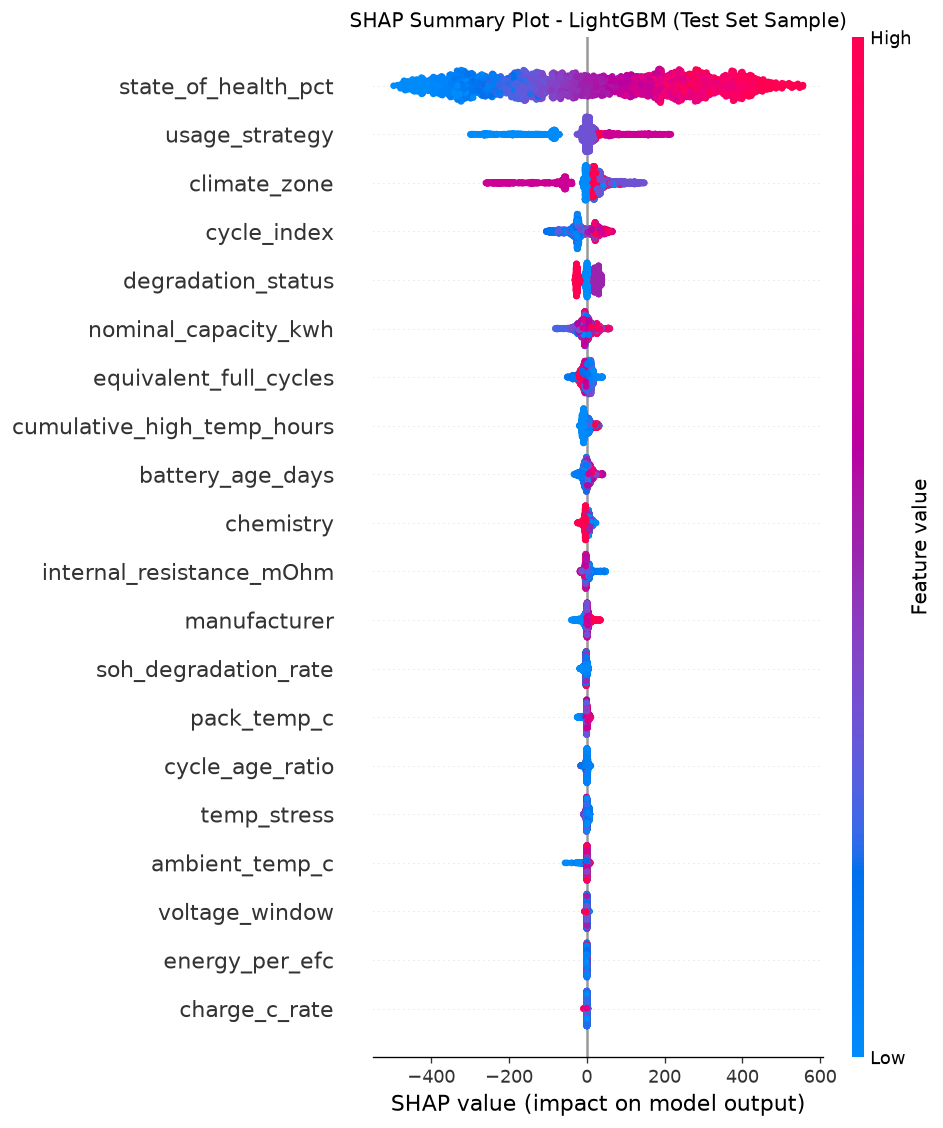

In [28]:
SHAP_SAMPLE = 3000
shap_idx    = np.random.choice(len(X_test_proc), size=min(SHAP_SAMPLE, len(X_test_proc)), replace=False)
X_shap      = X_test_proc[shap_idx]

explainer   = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=all_feature_names,
    show=False
)
plt.title('SHAP Summary Plot - LightGBM (Test Set Sample)')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'shap_summary.png'), bbox_inches='tight')
plt.show()

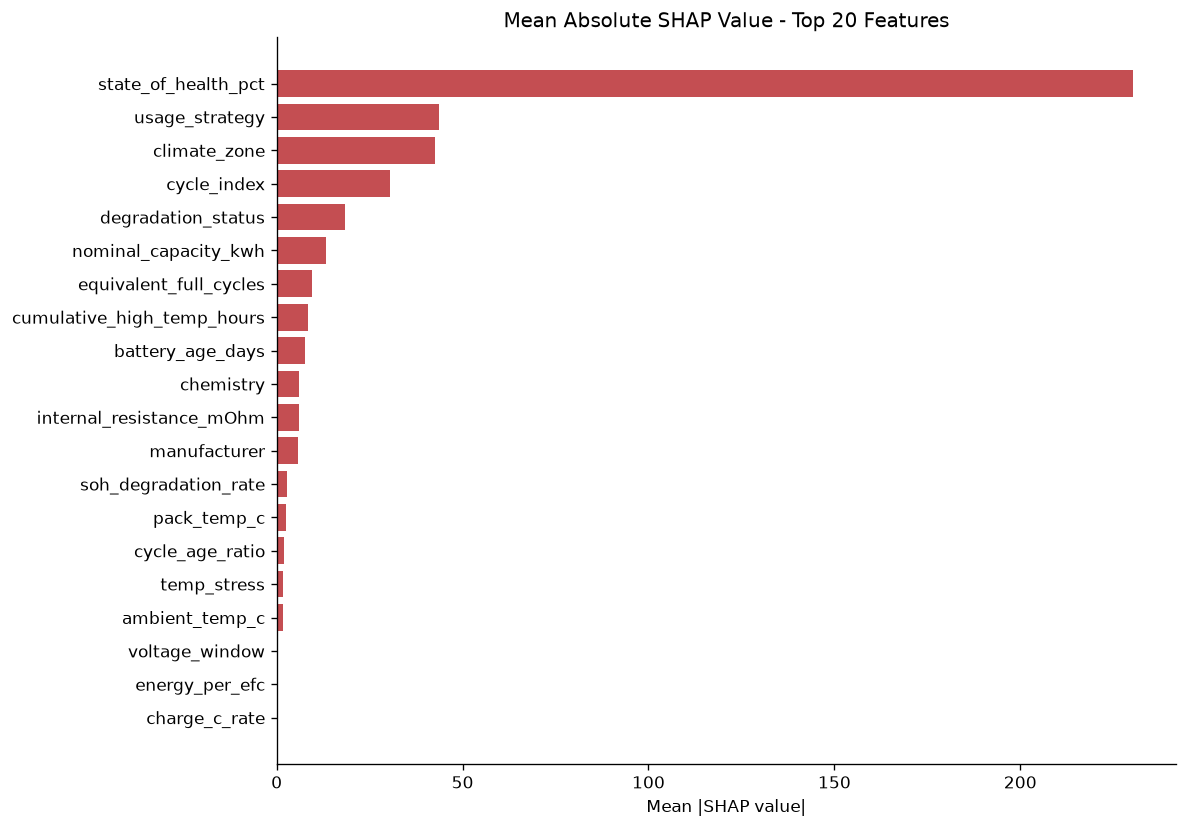

Top 10 features by SHAP:
state_of_health_pct           230.3525
usage_strategy                 43.7245
climate_zone                   42.4759
cycle_index                    30.3690
degradation_status             18.5037
nominal_capacity_kwh           13.2764
equivalent_full_cycles          9.3893
cumulative_high_temp_hours      8.4357
battery_age_days                7.7084
chemistry                       5.9563


In [29]:
shap_mean_abs = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=all_feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(shap_mean_abs.head(20).index[::-1], shap_mean_abs.head(20).values[::-1], color='#C44E52')
ax.set_title('Mean Absolute SHAP Value - Top 20 Features')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'shap_bar.png'), bbox_inches='tight')
plt.show()

print('Top 10 features by SHAP:')
print(shap_mean_abs.head(10).round(4).to_string())

### 13.3 SHAP Dependence Plots

Dependence plots reveal how the SHAP value of a feature changes as its value changes. Each point represents a single observation, and the pattern across all points exposes non-linear relationships and interaction effects.

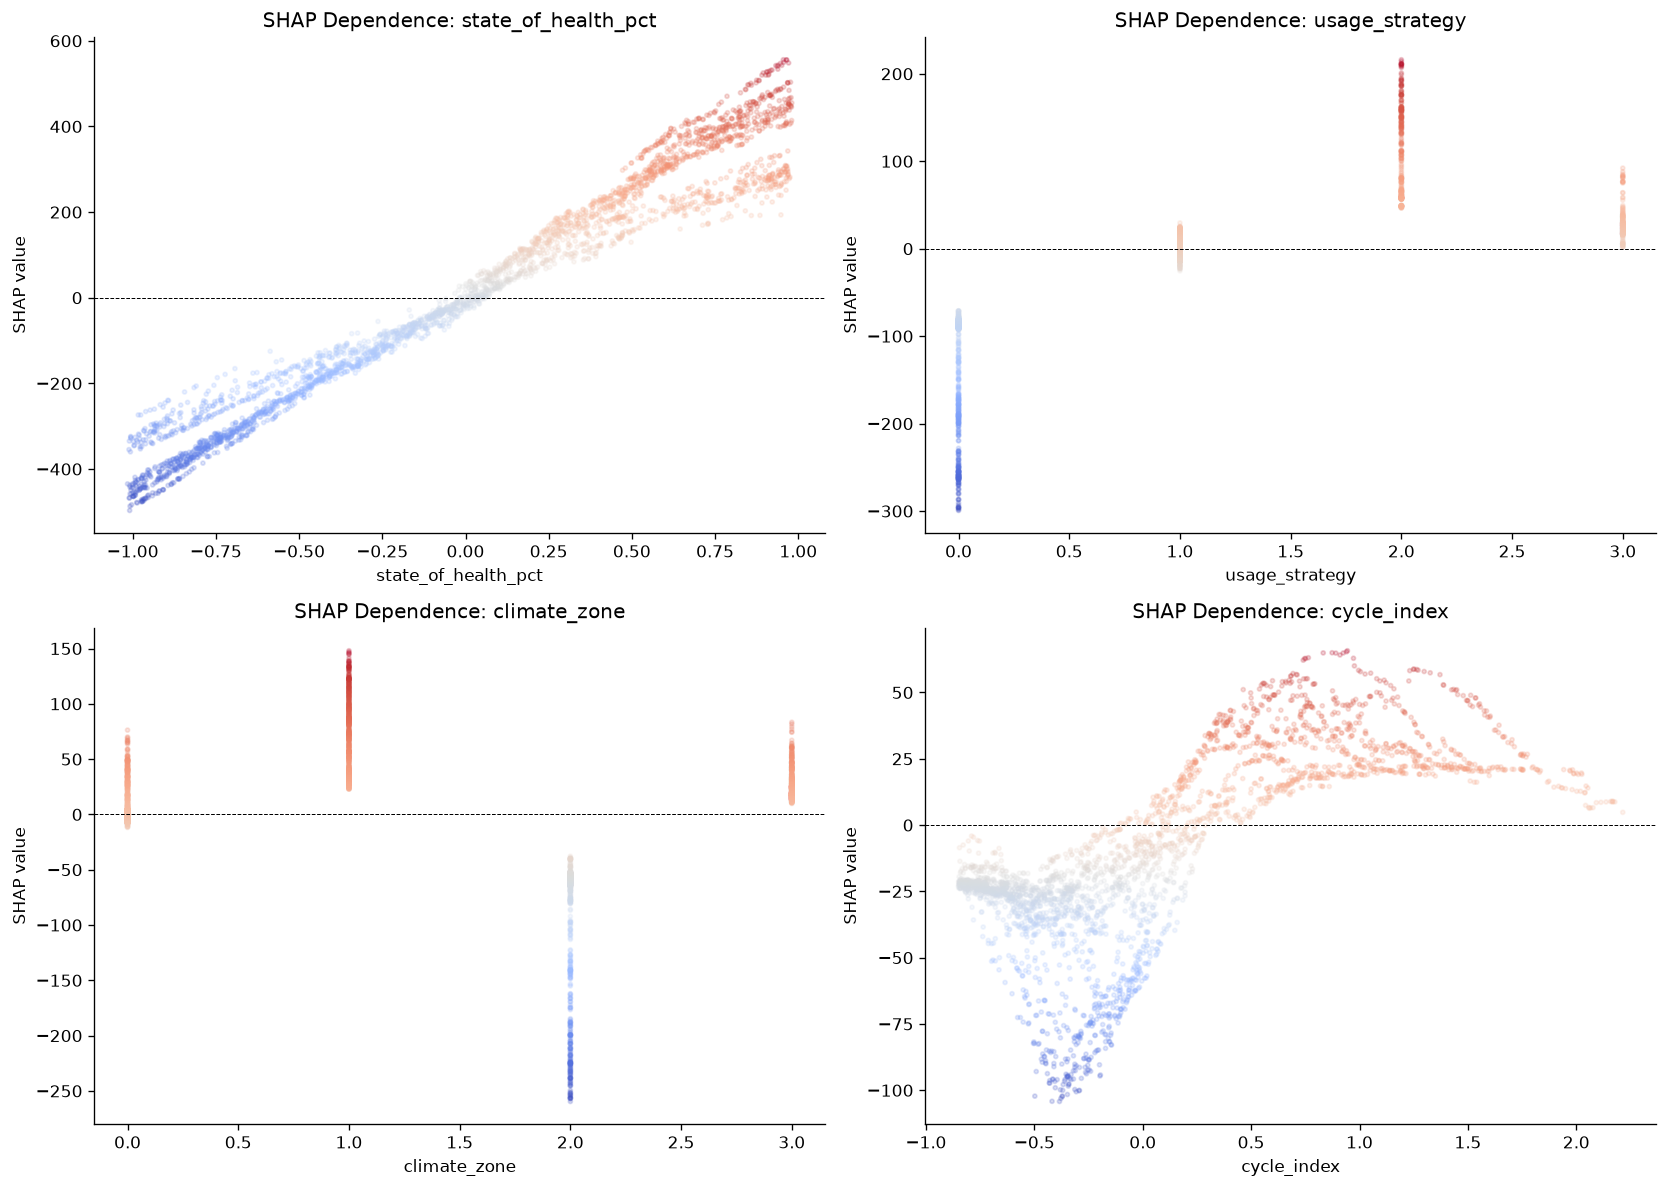

In [30]:
top_features = shap_mean_abs.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.ravel(), top_features):
    feat_idx = all_feature_names.index(feat)
    sc = ax.scatter(
        X_shap[:, feat_idx],
        shap_values[:, feat_idx],
        alpha=0.2, s=6, c=shap_values[:, feat_idx], cmap='coolwarm'
    )
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title('SHAP Dependence: ' + feat)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'shap_dependence.png'), bbox_inches='tight')
plt.show()

## 14. Summary and Artifact Export

This section consolidates the key findings and saves a structured JSON summary of the best model's performance and top features.

In [31]:
print('=' * 60)
print('FINAL TEST SET EVALUATION SUMMARY')
print('=' * 60)
print(final_df.to_string())
print()

best_model_name = final_df['RMSE'].idxmin()
best_metrics    = final_df.loc[best_model_name]

print('Best model  :', best_model_name)
print('Test MAE    :', round(best_metrics['MAE'], 2),  'cycles')
print('Test RMSE   :', round(best_metrics['RMSE'], 2), 'cycles')
print('Test MAPE   :', round(best_metrics['MAPE (%)'], 2), '%')
print('Test R2     :', round(best_metrics['R2'], 4))
print()
print('Top 5 predictive features (SHAP):')
for i, (feat, val) in enumerate(shap_mean_abs.head(5).items(), 1):
    print(' ', i, '.', feat.ljust(35), 'mean |SHAP| =', round(val, 4))

summary = {
    'best_model':         best_model_name,
    'test_mae':           float(best_metrics['MAE']),
    'test_rmse':          float(best_metrics['RMSE']),
    'test_mape_pct':      float(best_metrics['MAPE (%)']),
    'test_r2':            float(best_metrics['R2']),
    'top_features_shap':  {k: float(v) for k, v in shap_mean_abs.head(10).items()}
}

with open(os.path.join(MODEL_DIR, 'model_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print()
print('Model summary saved to model_artifacts/model_summary.json')

FINAL TEST SET EVALUATION SUMMARY
                      MAE     RMSE      MAPE (%)      R2
Model                                                   
XGBoost (tuned)   42.6897  66.1304  3.761493e+15  0.9592
LightGBM (tuned)  39.5356  61.9644  7.817283e+15  0.9642
CatBoost (tuned)  40.7587  59.8668  6.944219e+15  0.9665
Ensemble          39.4181  60.9811  6.211479e+15  0.9653

Best model  : CatBoost (tuned)
Test MAE    : 40.76 cycles
Test RMSE   : 59.87 cycles
Test MAPE   : 6944219413658732.0 %
Test R2     : 0.9665

Top 5 predictive features (SHAP):
  1 . state_of_health_pct                 mean |SHAP| = 230.3525
  2 . usage_strategy                      mean |SHAP| = 43.7245
  3 . climate_zone                        mean |SHAP| = 42.4759
  4 . cycle_index                         mean |SHAP| = 30.369
  5 . degradation_status                  mean |SHAP| = 18.5037

Model summary saved to model_artifacts/model_summary.json


## 15. Saved Artifacts

The following files have been saved to the `model_artifacts/` directory:

| File | Description |
|---|---|
| `preprocessor.joblib` | Fitted ColumnTransformer (imputer + scaler + encoder) |
| `best_xgboost.joblib` | Tuned XGBoost model trained on train+val |
| `best_lightgbm.joblib` | Tuned LightGBM model trained on train+val |
| `best_catboost.joblib` | Tuned CatBoost model trained on train+val |
| `ensemble_weights.json` | Inverse-RMSE ensemble weights for the three models |
| `test_evaluation_results.csv` | Per-model metric table on the test set |
| `model_summary.json` | Best model summary with top SHAP features |
| `target_distribution.png` | Raw and log-transformed target histograms with Q-Q plot |
| `target_by_category.png` | Target distribution broken down by categorical metadata |
| `feature_correlation.png` | Pearson correlation of all numeric features with target |
| `degradation_trajectories.png` | SoH and RUC degradation curves for sample batteries |
| `baseline_comparison.png` | Baseline model RMSE and R2 comparison charts |
| `optuna_history.png` | Hyperparameter optimization convergence curves |
| `residual_analysis.png` | Residual plots for the ensemble on the test set |
| `error_by_segment.png` | Absolute error by degradation status and battery chemistry |
| `feature_importance_native.png` | Gain-based importance from XGBoost and LightGBM |
| `shap_summary.png` | SHAP beeswarm summary plot |
| `shap_bar.png` | Mean absolute SHAP value bar chart |
| `shap_dependence.png` | SHAP dependence plots for the top 4 features |